In [ ]:
# EDA Segment Analysis

## Purpose

This notebook performs segment-level exploratory data analysis on the StanzaOps hostel dataset.

## Main Tasks

- Analyse residents by gender
- Analyse residents by city
- Analyse residents by state
- Compare payment performance across segments
- Generate segment-based business insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("Hostel_Management_Dataset_Filled.csv")

In [5]:
df.head()

,Resident_ID,Resident_Name,Gender,Date_of_Birth,Mobile_Number,Email,Aadhaar_Number,Company_Name,Employee_ID,Occupation,...,Religion,ID_Proof_Type,Aadhaar_Copy,Voter_ID_Copy,Joining_Date,Exit_Date,Bed_Status,Room_Capacity,Available_Beds,Remarks
0,R00001,Resident 1,Male,1991-02-02,800000001,resident1@example.com,100000000001,Infosys,EMP00001,Analyst,...,Hindu,Aadhaar,Yes,Yes,2026-01-01,NaN,Occupied,2,0,NaN
1,R00002,Resident 2,Female,1992-03-03,800000002,resident2@example.com,100000000002,Wipro,EMP00002,Tester,...,Hindu,Aadhaar,Yes,Yes,2026-01-01,NaN,Occupied,2,0,NaN
2,R00003,Resident 3,Male,1993-04-04,800000003,resident3@example.com,100000000003,Accenture,EMP00003,Support Engineer,...,Hindu,Aadhaar,Yes,Yes,2026-01-01,NaN,Occupied,2,0,NaN
3,R00004,Resident 4,Female,1994-05-05,800000004,resident4@example.com,100000000004,Capgemini,EMP00004,Software Engineer,...,Hindu,Aadhaar,Yes,Yes,2026-01-01,NaN,Occupied,2,1,NaN
4,R00005,Resident 5,Male,1995-06-06,800000005,resident5@example.com,100000000005,TCS,EMP00005,Analyst,...,Hindu,Aadhaar,Yes,Yes,2026-01-01,NaN,Occupied,2,0,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Resident_ID        10000 non-null  object 
 1   Resident_Name      10000 non-null  object 
 2   Gender             10000 non-null  object 
 3   Date_of_Birth      10000 non-null  object 
 4   Mobile_Number      10000 non-null  int64  
 5   Email              10000 non-null  object 
 6   Aadhaar_Number     10000 non-null  int64  
 7   Company_Name       10000 non-null  object 
 8   Employee_ID        10000 non-null  object 
 9   Occupation         10000 non-null  object 
 10  Check_In_Date      10000 non-null  object 
 11  Check_Out_Date     0 non-null      float64
 12  Room_Number        10000 non-null  object 
 13  Bed_Number         10000 non-null  object 
 14  Room_Type          10000 non-null  object 
 15  Floor              10000 non-null  int64  
 16  Monthly_Rent       1000

In [8]:
df.shape

(10000, 43)

In [33]:
df.shape

(10000, 44)

In [16]:
today = pd.Timestamp.today()
df["Age"] = ((today - df["Date_of_Birth"]).dt.days / 365.25).astype(int)

In [17]:
df[["Date_of_Birth", "Age"]].head()

,Date_of_Birth,Age
0,1991-02-02,35
1,1992-03-03,34
2,1993-04-04,33
3,1994-05-05,32
4,1995-06-06,31


In [22]:
### EDA On Amount_Paid ##
df["Age"].describe()

count    10000.000000
mean        31.083500
std          2.928205
min         26.000000
25%         29.000000
50%         31.000000
75%         34.000000
max         36.000000
Name: Age, dtype: float64

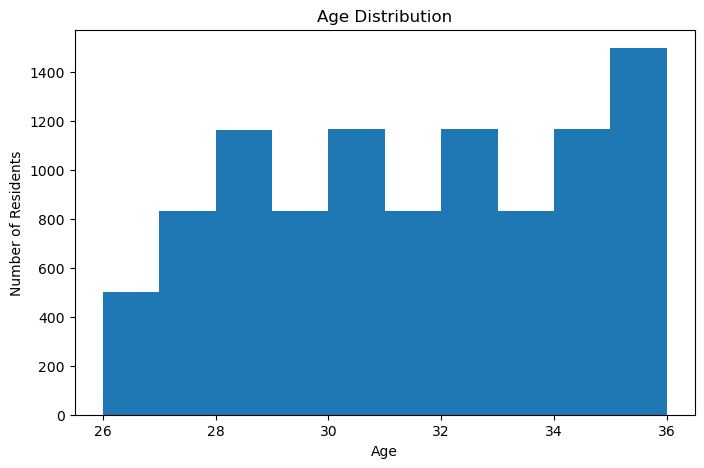

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Residents")
plt.show()

In [24]:
df["Deposit_Amount"].describe()

count    10000.0
mean     10000.0
std          0.0
min      10000.0
25%      10000.0
50%      10000.0
75%      10000.0
max      10000.0
Name: Deposit_Amount, dtype: float64

In [25]:
df["Deposit_Amount"].isnull().sum()

np.int64(0)

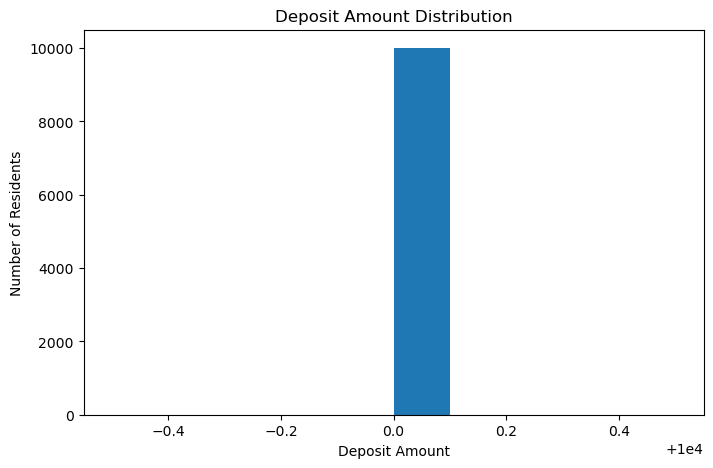

In [26]:
# Deposit Amount Distribution

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Deposit_Amount"], bins=10)
plt.title("Deposit Amount Distribution")
plt.xlabel("Deposit Amount")
plt.ylabel("Number of Residents")
plt.show()

In [27]:
print("Minimum Deposit:", df["Deposit_Amount"].min())
print("Maximum Deposit:", df["Deposit_Amount"].max())

Minimum Deposit: 10000
Maximum Deposit: 10000


In [28]:
print("Average Deposit:", df["Deposit_Amount"].mean())

Average Deposit: 10000.0


In [29]:
df["Amount_Paid"].isnull().sum()

np.int64(0)

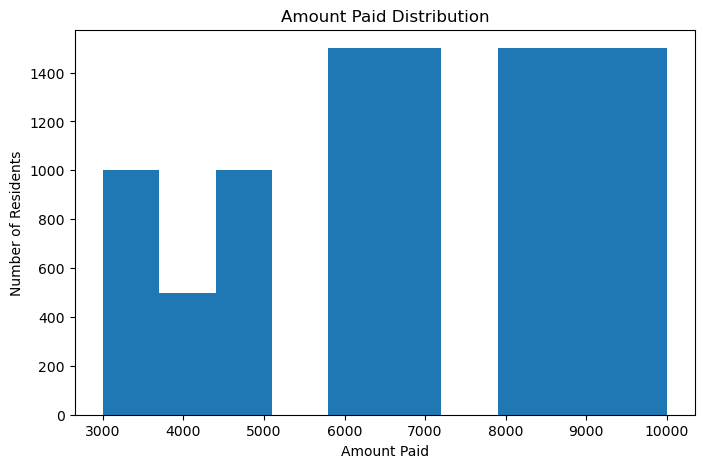

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Amount_Paid"], bins=10)
plt.title("Amount Paid Distribution")
plt.xlabel("Amount Paid")
plt.ylabel("Number of Residents")
plt.show()

In [31]:
print("Minimum Amount Paid:", df["Amount_Paid"].min())
print("Maximum Amount Paid:", df["Amount_Paid"].max())

Minimum Amount Paid: 3000
Maximum Amount Paid: 10000


In [32]:
print("Average Amount Paid:", df["Amount_Paid"].mean())

Average Amount Paid: 7000.0


In [34]:
df["Amount_Paid"].describe()

count    10000.000000
mean      7000.000000
std       2150.688854
min       3000.000000
25%       5750.000000
50%       7000.000000
75%       9000.000000
max      10000.000000
Name: Amount_Paid, dtype: float64

In [35]:
df.groupby("Gender")[["Age","Deposit_Amount","Amount_Paid"]].agg(["count","mean","sum"])

Age                  Deposit_Amount                    Amount_Paid  \
       count     mean     sum          count     mean       sum       count   
Gender                                                                        
Female  5000  31.6668  158334           5000  10000.0  50000000        5000   
Male    5000  30.5002  152501           5000  10000.0  50000000        5000   

                          
          mean       sum  
Gender                    
Female  6000.0  30000000  
Male    8000.0  40000000

In [36]:
df.groupby("City")[["Age","Deposit_Amount","Amount_Paid"]].agg(["count","mean","sum"])

Age                 Deposit_Amount                     \
           count     mean    sum          count     mean       sum   
City                                                                 
Chennai     2500  30.3336  75834           2500  10000.0  25000000   
Guntur      2500  31.6668  79167           2500  10000.0  25000000   
Hyderabad   2500  31.6668  79167           2500  10000.0  25000000   
Vijayawada  2500  30.6668  76667           2500  10000.0  25000000   

           Amount_Paid                    
                 count    mean       sum  
City                                      
Chennai           2500  8000.0  20000000  
Guntur            2500  4000.0  10000000  
Hyderabad         2500  8000.0  20000000  
Vijayawada        2500  8000.0  20000000

In [37]:
df.groupby("State")[["Age","Deposit_Amount","Amount_Paid"]].agg(["count","mean","sum"])

Age                  Deposit_Amount                     \
               count     mean     sum          count     mean       sum   
State                                                                     
Andhra Pradesh  5000  31.1668  155834           5000  10000.0  50000000   
Tamil Nadu      2500  30.3336   75834           2500  10000.0  25000000   
Telangana       2500  31.6668   79167           2500  10000.0  25000000   

               Amount_Paid                    
                     count    mean       sum  
State                                         
Andhra Pradesh        5000  6000.0  30000000  
Tamil Nadu            2500  8000.0  20000000  
Telangana             2500  8000.0  20000000

In [40]:
df["Date_of_Birth"] = pd.to_datetime(df["Date_of_Birth"])
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"])

df["Birth_Year"] = df["Date_of_Birth"].dt.year
df["Birth_Month"] = df["Date_of_Birth"].dt.month
df["Birth_Day"] = df["Date_of_Birth"].dt.day

df["Joining_Year"] = df["Joining_Date"].dt.year
df["Joining_Month"] = df["Joining_Date"].dt.month
df["Joining_Day"] = df["Joining_Date"].dt.day

In [41]:
df.head()

,Resident_ID,Resident_Name,Gender,Date_of_Birth,Mobile_Number,Email,Aadhaar_Number,Company_Name,Employee_ID,Occupation,...,Room_Capacity,Available_Beds,Remarks,Age,Birth_Year,Birth_Month,Birth_Day,Joining_Year,Joining_Month,Joining_Day
0,R00001,Resident 1,Male,1991-02-02,800000001,resident1@example.com,100000000001,Infosys,EMP00001,Analyst,...,2,0,NaN,35,1991,2,2,2026,1,1
1,R00002,Resident 2,Female,1992-03-03,800000002,resident2@example.com,100000000002,Wipro,EMP00002,Tester,...,2,0,NaN,34,1992,3,3,2026,1,1
2,R00003,Resident 3,Male,1993-04-04,800000003,resident3@example.com,100000000003,Accenture,EMP00003,Support Engineer,...,2,0,NaN,33,1993,4,4,2026,1,1
3,R00004,Resident 4,Female,1994-05-05,800000004,resident4@example.com,100000000004,Capgemini,EMP00004,Software Engineer,...,2,1,NaN,32,1994,5,5,2026,1,1
4,R00005,Resident 5,Male,1995-06-06,800000005,resident5@example.com,100000000005,TCS,EMP00005,Analyst,...,2,0,NaN,31,1995,6,6,2026,1,1


In [43]:
df[[
    "Date_of_Birth",
    "Birth_Year",
    "Birth_Month",
    "Birth_Day",
    "Joining_Date",
    "Joining_Year",
    "Joining_Month",
    "Joining_Day"
]].head()

,Date_of_Birth,Birth_Year,Birth_Month,Birth_Day,Joining_Date,Joining_Year,Joining_Month,Joining_Day
0,1991-02-02,1991,2,2,2026-01-01,2026,1,1
1,1992-03-03,1992,3,3,2026-01-01,2026,1,1
2,1993-04-04,1993,4,4,2026-01-01,2026,1,1
3,1994-05-05,1994,5,5,2026-01-01,2026,1,1
4,1995-06-06,1995,6,6,2026-01-01,2026,1,1
